In [2]:
# Add a divider line
print(f" {'=' *50}")
print("# CODVEDA INTERNSHIP | Level 1 | Task 3: Data Visualization")
print("# Dataset: iris_clean.csv")
print(f"{'=' *50}")

# CODVEDA INTERNSHIP | Level 1 | Task 3: Data Visualization
# Dataset: iris_clean.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

COLORS = {
    'setosa'     : '#2196F3',  # blue
    'versicolor' : '#FF9800',  # orange
    'virginica'  : '#4CAF50'   # green
}

In [9]:
#load Dataset
df_iris_clean = pd.read_csv('iris_clean.csv')

In [10]:
# to create a folder called plot
os.makedirs('plots', exist_ok=True)

# BAR PLOT - average feature values per species
Data being plotted:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.60,2.98,5.56,2.03


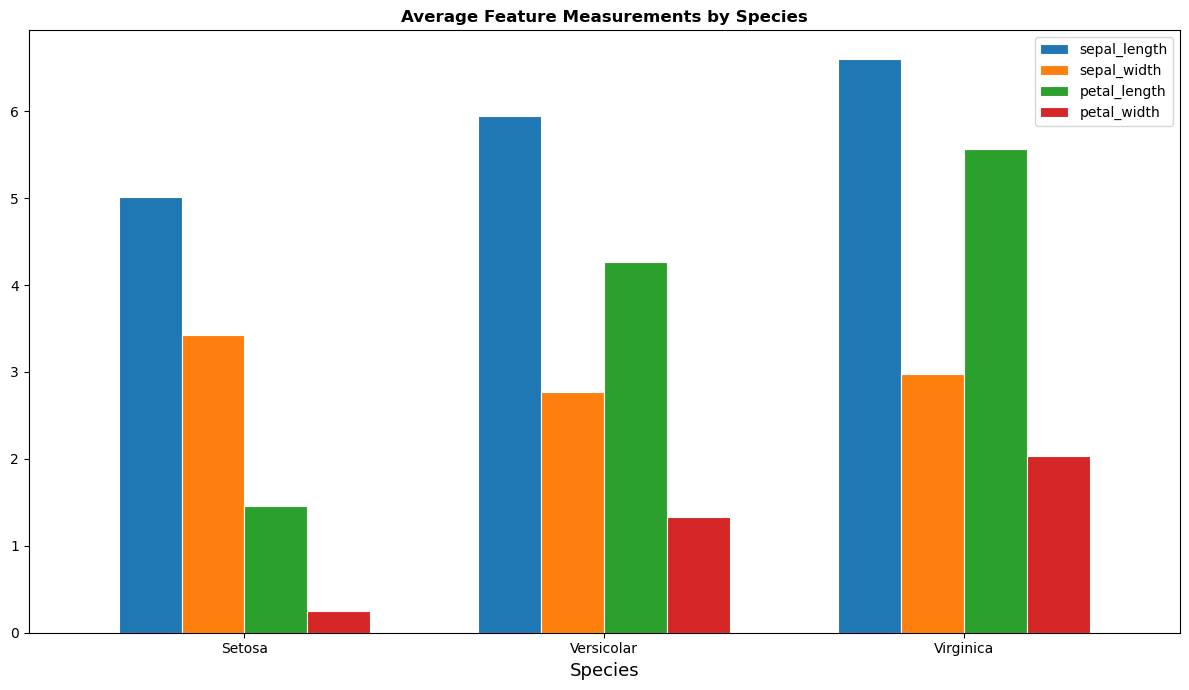

In [11]:
# Add a divider line
print(f" {'=' *50}")
print("# BAR PLOT - average feature values per species")
print(f"{'=' *50}")

# mean of each specie
species_means = df_iris_clean.groupby('species').mean().round(2)

print("Data being plotted:")
display(species_means)

# create a figure object
fig, ax = plt.subplots(figsize=(12,7))

# plot a bar chat
species_means.plot(
    #data=species_means,
    kind='bar',
    ax=ax,
    width=0.7,
    edgecolor='white',
    linewidth=0.8
)

#title and labels
ax.set_title('Average Feature Measurements by Species', fontweight='bold')
ax.set_xlabel('Species', fontsize=13)
ax.set_xticklabels(
    ['Setosa', 'Versicolar', 'Virginica'],
    rotation=0,
    ha='center'
)
plt.tight_layout()
plt.savefig('plots/bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

LINE CHART — feature values across individual samples


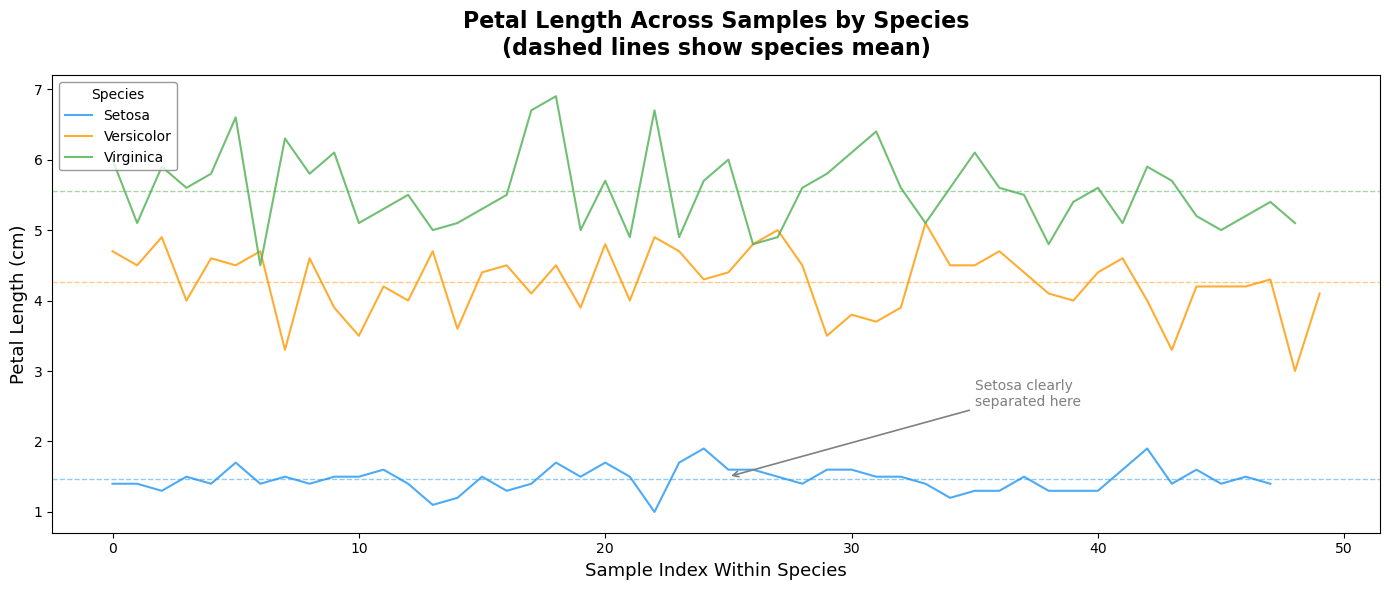

✅ Saved: plots/line_chart.png


In [13]:
# ============================================================
# LINE CHART — feature values across individual samples
# shows trends and variation within each species
# ============================================================
print(f" {'=' *50}")
print("LINE CHART — feature values across individual samples")
print(f"{'=' *50}")

fig, ax = plt.subplots(figsize=(14, 6))

# we plot petal_length across all samples
# colored by species to show how values shift between groups
# first separate the dataset by species
for species, color in COLORS.items():
    
    # filter rows for this specific species only
    # df[df['species'] == species] returns only matching rows
    subset = df_iris_clean[df_iris_clean['species'] == species].reset_index(drop=True)
    
    # reset_index(drop=True) resets row numbers to 0,1,2...
    # drop=True means don't keep old index as a column
    # we need clean sequential numbers for the x-axis
    
    # ax.plot draws a line chart
    # subset.index → x-axis (sample number within species)
    # subset['petal_length'] → y-axis (the measurement)
    # color=color → use our custom color for this species
    # label=species → name shown in legend
    # linewidth=1.5 → line thickness
    # alpha=0.8 → slight transparency so overlapping lines show
    ax.plot(
        subset.index,
        subset['petal_length'],
        color=color,
        label=species.capitalize(),
        linewidth=1.5,
        alpha=0.8
    )
    
    # add a horizontal dashed line showing the mean
    # this lets you see how much individual samples vary
    # around their species average
    ax.axhline(
        y=subset['petal_length'].mean(),
        color=color,
        linestyle='--',      # dashed line style
        linewidth=1,
        alpha=0.5            # more transparent than the main line
    )

# ── LABELS AND TITLE ──────────────────────────────────────
ax.set_title(
    'Petal Length Across Samples by Species\n'
    '(dashed lines show species mean)',
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Sample Index Within Species', fontsize=13)
ax.set_ylabel('Petal Length (cm)', fontsize=13)

# ── LEGEND ────────────────────────────────────────────────
ax.legend(
    title='Species',
    loc='upper left',
    frameon=True,
    edgecolor='gray'
)

# ── ANNOTATIONS ───────────────────────────────────────────
# ax.annotate adds a text label with an arrow pointing
# to a specific location on the chart
# this draws attention to the key insight
ax.annotate(
    'Setosa clearly\nseparated here',
    xy=(25, 1.5),          # arrow tip location (x, y)
    xytext=(35, 2.5),      # text location (x, y)
    fontsize=10,
    color='gray',
    arrowprops=dict(
        arrowstyle='->',   # arrow head style
        color='gray',
        lw=1.2             # arrow line width
    )
)

plt.tight_layout()
plt.savefig('plots/line_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/line_chart.png")

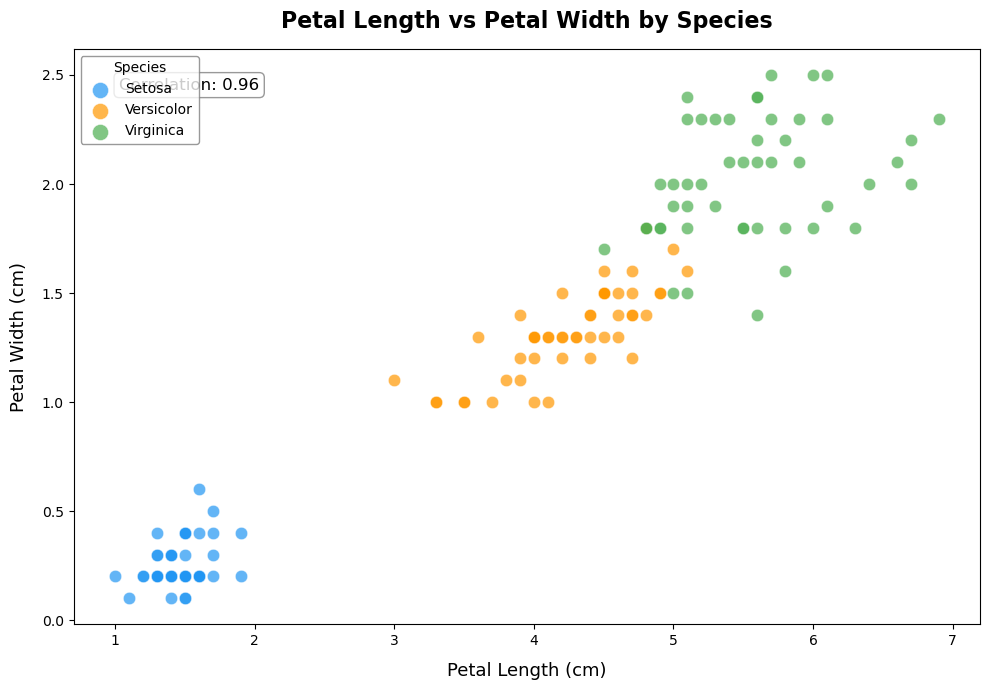

✅ Saved: plots/scatter_plot.png


In [18]:
# ============================================================
# SCATTER PLOT — petal length vs petal width
# the most important feature relationship in the dataset
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# plot each species separately so we can control
# color, label and marker style individually
for species, color in COLORS.items():
    subset = df_iris_clean[df_iris_clean['species'] == species]
    
    # ax.scatter draws individual dots
    # x and y are the two features being compared
    # c=color → dot color
    # label → legend entry
    # s=80 → dot size (in points squared)
    # alpha → transparency (overlapping dots still visible)
    # edgecolors → thin border around each dot
    # linewidths → thickness of that border
    ax.scatter(
        x=subset['petal_length'],
        y=subset['petal_width'],
        c=color,
        label=species.capitalize(),
        s=80,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5
    )

# ── TITLE AND LABELS ──────────────────────────────────────
ax.set_title(
    'Petal Length vs Petal Width by Species',
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Petal Length (cm)', fontsize=13, labelpad=10)
ax.set_ylabel('Petal Width (cm)', fontsize=13, labelpad=10)

# ── LEGEND ────────────────────────────────────────────────
ax.legend(
    title='Species',
    loc='upper left',
    frameon=True,
    edgecolor='gray',
    markerscale=1.3   # makes legend dots slightly bigger
)

# ── CORRELATION ANNOTATION ────────────────────────────────
# calculate and display correlation directly on the chart
# so the reader has the number without looking elsewhere
corr = df_iris_clean['petal_length'].corr(df_iris_clean['petal_width'])

# ax.text places text at a specific x,y coordinate
# transform=ax.transAxes means use 0-1 coor_dinate system
# so (0.05, 0.95) = 5% from left, 95% from bottom
# regardless of actual data values
ax.text(
    0.05, 0.95,
    f'Correlation: {corr:.2f}',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',    # rounded rectangle background
        facecolor='white',
        alpha=0.8,
        edgecolor='gray'
    )
)

plt.tight_layout()
plt.savefig('plots/scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/scatter_plot.png")

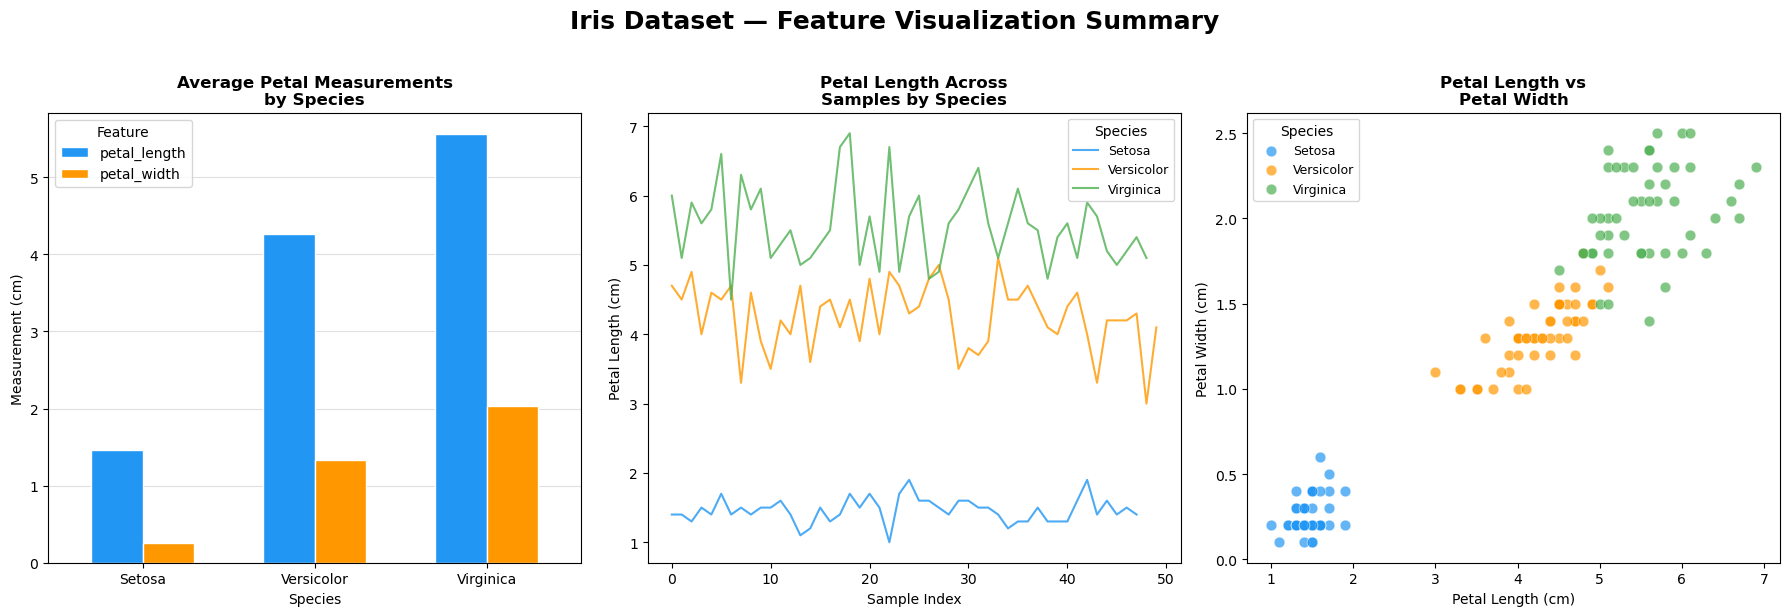

✅ Saved: plots/combined_visualization.png
   This is your main submission chart for Task 3


In [19]:
# ============================================================
# COMBINED FIGURE — all charts in one exportable image
# this is what you include in your submission report
# ============================================================

# creates a figure with 1 row and 3 columns of subplots
# figsize=(18, 6) makes it wide enough for all three side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── CHART 1: BAR PLOT ─────────────────────────────────────
species_means = df_iris_clean.groupby('species').mean().round(2)
species_means[['petal_length', 'petal_width']].plot(
    kind='bar',
    ax=axes[0],
    color=['#2196F3', '#FF9800'],
    width=0.6,
    edgecolor='white'
)
axes[0].set_title('Average Petal Measurements\nby Species', fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Measurement (cm)')
axes[0].set_xticklabels(['Setosa', 'Versicolor', 'Virginica'], rotation=0)
axes[0].legend(title='Feature')
axes[0].yaxis.grid(True, alpha=0.4)
axes[0].set_axisbelow(True)

# ── CHART 2: LINE CHART ───────────────────────────────────
for species, color in COLORS.items():
    subset = df_iris_clean[df_iris_clean['species'] == species].reset_index(drop=True)
    axes[1].plot(
        subset.index,
        subset['petal_length'],
        color=color,
        label=species.capitalize(),
        linewidth=1.5,
        alpha=0.8
    )
axes[1].set_title('Petal Length Across\nSamples by Species', fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Petal Length (cm)')
axes[1].legend(title='Species', fontsize=9)

# ── CHART 3: SCATTER PLOT ─────────────────────────────────
for species, color in COLORS.items():
    subset = df_iris_clean[df_iris_clean['species'] == species]
    axes[2].scatter(
        subset['petal_length'],
        subset['petal_width'],
        c=color,
        label=species.capitalize(),
        s=60,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5
    )
axes[2].set_title('Petal Length vs\nPetal Width', fontweight='bold')
axes[2].set_xlabel('Petal Length (cm)')
axes[2].set_ylabel('Petal Width (cm)')
axes[2].legend(title='Species', fontsize=9)

# ── OVERALL TITLE ─────────────────────────────────────────
# suptitle adds one master title above all three charts
fig.suptitle(
    'Iris Dataset — Feature Visualization Summary',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    'plots/combined_visualization.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("✅ Saved: plots/combined_visualization.png")
print("   This is your main submission chart for Task 3")

In [20]:
# ============================================================
# CONFIRM ALL FILES SAVED CORRECTLY
# ============================================================

import os

# os.listdir returns all files in the plots folder
saved_files = os.listdir('plots')

print("=" * 40)
print("TASK 3 — SAVED FILES")
print("=" * 40)
for f in sorted(saved_files):
    # os.path.join builds the full file path
    # os.path.getsize returns file size in bytes
    size = os.path.getsize(os.path.join('plots', f))
    print(f"  {f:<35} {size/1024:.1f} KB")

print("\n✅ Task 3 Complete!")
print("   All plots exported to plots/ folder")
print("   Ready for submission")

TASK 3 — SAVED FILES
  .ipynb_checkpoints                  4.0 KB
  Boxplot.png                         94.3 KB
  Heatmap.png                         60.9 KB
  Pairplot.png                        441.2 KB
  bar_chart.png                       42.6 KB
  combined_visualization.png          203.4 KB
  histograms.png                      260.3 KB
  histograms_hue.png                  260.3 KB
  line_chart.png                      179.0 KB
  scatter_plot.png                    73.5 KB

✅ Task 3 Complete!
   All plots exported to plots/ folder
   Ready for submission
